## 1. Data 

In [1]:
import pandas as pd

In [2]:
file_path = "listings_newyork.xlsx"
listing = pd.read_excel(file_path)

In [3]:
import pandas as pd

In [4]:
listing.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,40824219,https://www.airbnb.com/rooms/40824219,20251001171547,2025-10-02,city scrape,Room close to Manhattan for FEMALE guests,This cozy spacious room includes a twin size b...,Sunnyside is a safe residental area. <br />The...,https://a0.muscache.com/pictures/hosting/Hosti...,317540555,...,4.88,4.94,4.69,NaN,f,3,0,3,0,0.23
1,40833186,https://www.airbnb.com/rooms/40833186,20251001171547,2025-10-02,previous scrape,Soho LES East village private room downtown,NaN,NaN,https://a0.muscache.com/pictures/1f093bbc-936c...,68718914,...,NaN,NaN,NaN,NaN,t,1,0,1,0,NaN
2,40837137,https://www.airbnb.com/rooms/40837137,20251001171547,2025-10-02,previous scrape,Sunset Park - Quiet and close to subway!,"Cozy, lovely bedroom with a comfortable full s...",the sunset park of Brooklyn,https://a0.muscache.com/pictures/01c4e91e-4012...,317770098,...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.01
3,40838018,https://www.airbnb.com/rooms/40838018,20251001171547,2025-10-02,previous scrape,Cozy One Bedroom in Clinton Hill,This sunny one-bedroom apartment is located in...,Clinton Hill is one of the best neighborhoods ...,https://a0.muscache.com/pictures/9322d54a-6eb7...,17211451,...,5.00,5.00,5.00,NaN,t,1,1,0,0,0.01
4,40839416,https://www.airbnb.com/rooms/40839416,20251001171547,2025-10-02,city scrape,ðŸª´XL dojo ðŸŒ¾ shared green yogi palace apt ...,"New York City living at its best. A massive, c...",Live like the Ramones > The East Village is st...,https://a0.muscache.com/pictures/hosting/Hosti...,4765305,...,5.00,5.00,4.95,NaN,f,8,0,8,0,0.40


## *Observation

In [5]:
newyork = listing.copy()

In [6]:
newyork.shape #36111 observations, 79 columns

(36111, 79)

In [7]:
newyork.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [8]:
#Check outliers and correlation of numerical values only

In [9]:
# Select numeric columns only
numeric_cols = newyork.select_dtypes(include=['float64', 'int64']).columns

In [10]:
from matplotlib import pyplot as plt

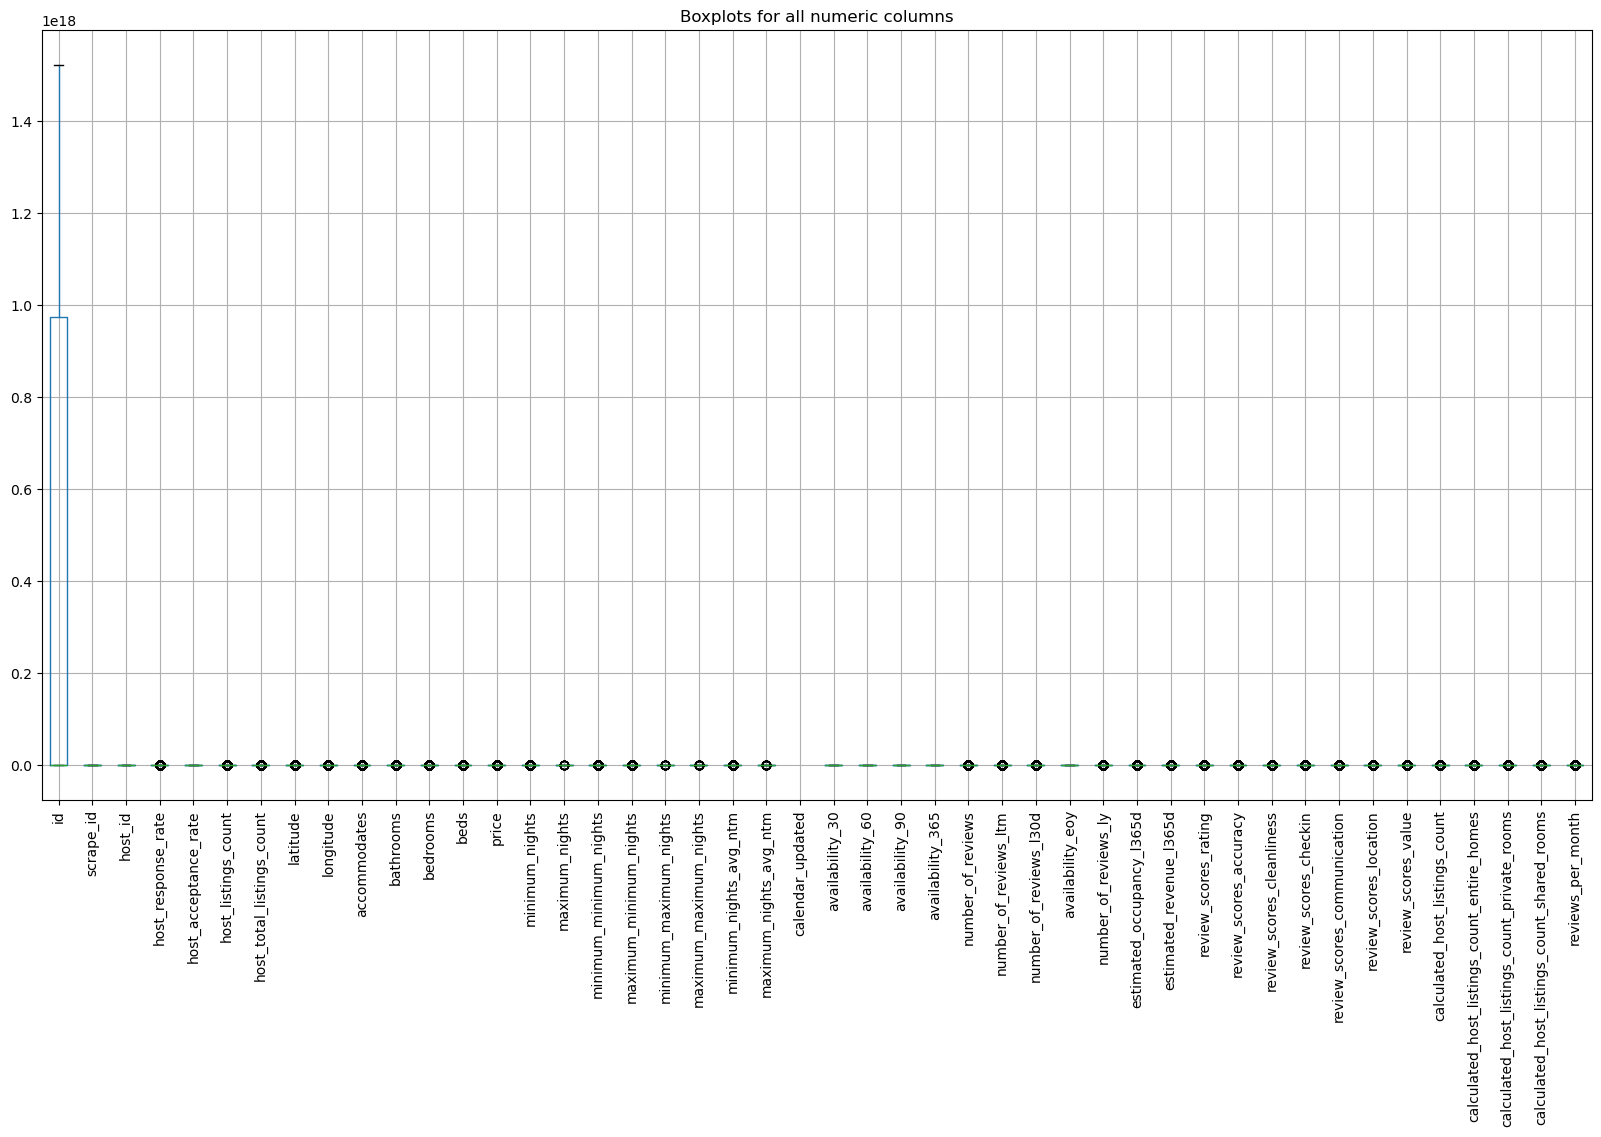

In [11]:
newyork[numeric_cols].boxplot(figsize=(20,10), rot=90)
plt.title('Boxplots for all numeric columns')
plt.show()

In [12]:
import seaborn as sns

In [13]:
sub = newyork[numeric_cols].copy()
sub = sub.drop(columns=['calendar_updated', 'scrape_id'], errors='ignore')

In [14]:
corr1 = sub.corr()
corr1

,id,host_id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
id,1.000000,0.499500,0.071690,0.032316,0.192507,0.203039,0.001592,0.014246,0.044791,0.038329,...,0.004847,-0.062544,-0.083379,-0.068102,-0.118760,0.205470,0.177630,0.088776,0.082792,0.202290
host_id,0.499500,1.000000,0.054254,0.133635,0.170723,0.158298,0.000460,0.092746,0.072474,-0.026153,...,-0.022863,-0.101850,-0.121354,-0.088348,-0.133348,-0.063667,-0.051882,-0.055763,0.050678,0.243275
host_response_rate,0.071690,0.054254,1.000000,0.428665,0.089575,0.103526,0.012475,0.027306,-0.008326,-0.005577,...,0.044157,0.026509,0.046855,-0.010822,0.011182,0.101696,0.010898,0.102055,0.010133,0.103954
host_acceptance_rate,0.032316,0.133635,0.428665,1.000000,-0.143196,-0.127498,0.018008,0.040701,0.111134,-0.023704,...,0.069308,0.020948,0.036850,-0.011528,0.017149,-0.296172,-0.086951,-0.288834,0.039907,0.209836
host_listings_count,0.192507,0.170723,0.089575,-0.143196,1.000000,0.929975,0.055982,-0.092711,-0.013934,-0.024217,...,-0.075550,-0.090489,-0.130012,-0.049613,-0.147989,0.469939,0.633040,0.124754,-0.009572,-0.035819
host_total_listings_count,0.203039,0.158298,0.103526,-0.127498,0.929975,1.000000,0.055849,-0.097694,0.005167,-0.006172,...,-0.066875,-0.093578,-0.123067,-0.050332,-0.139422,0.515538,0.527941,0.215780,-0.012190,-0.021011
latitude,0.001592,0.000460,0.012475,0.018008,0.055982,0.055849,1.000000,0.041180,-0.015962,-0.038254,...,-0.053800,-0.042635,-0.049693,0.014717,-0.062095,0.060417,0.074946,-0.033751,-0.013309,-0.042282
longitude,0.014246,0.092746,0.027306,0.040701,-0.092711,-0.097694,0.041180,1.000000,-0.021688,0.002667,...,0.022857,0.012165,0.013970,-0.137439,0.031659,-0.117571,-0.148053,0.067635,0.018557,0.023880
accommodates,0.044791,0.072474,-0.008326,0.111134,-0.013934,0.005167,-0.015962,-0.021688,1.000000,0.386206,...,0.032500,-0.006534,0.011390,-0.001858,-0.008065,-0.058595,-0.002129,-0.162549,-0.053537,0.034898
bathrooms,0.038329,-0.026153,-0.005577,-0.023704,-0.024217,-0.006172,-0.038254,0.002667,0.386206,1.000000,...,0.013949,0.007095,0.012800,-0.002022,0.021276,0.018619,-0.010526,0.083205,0.077051,-0.039762


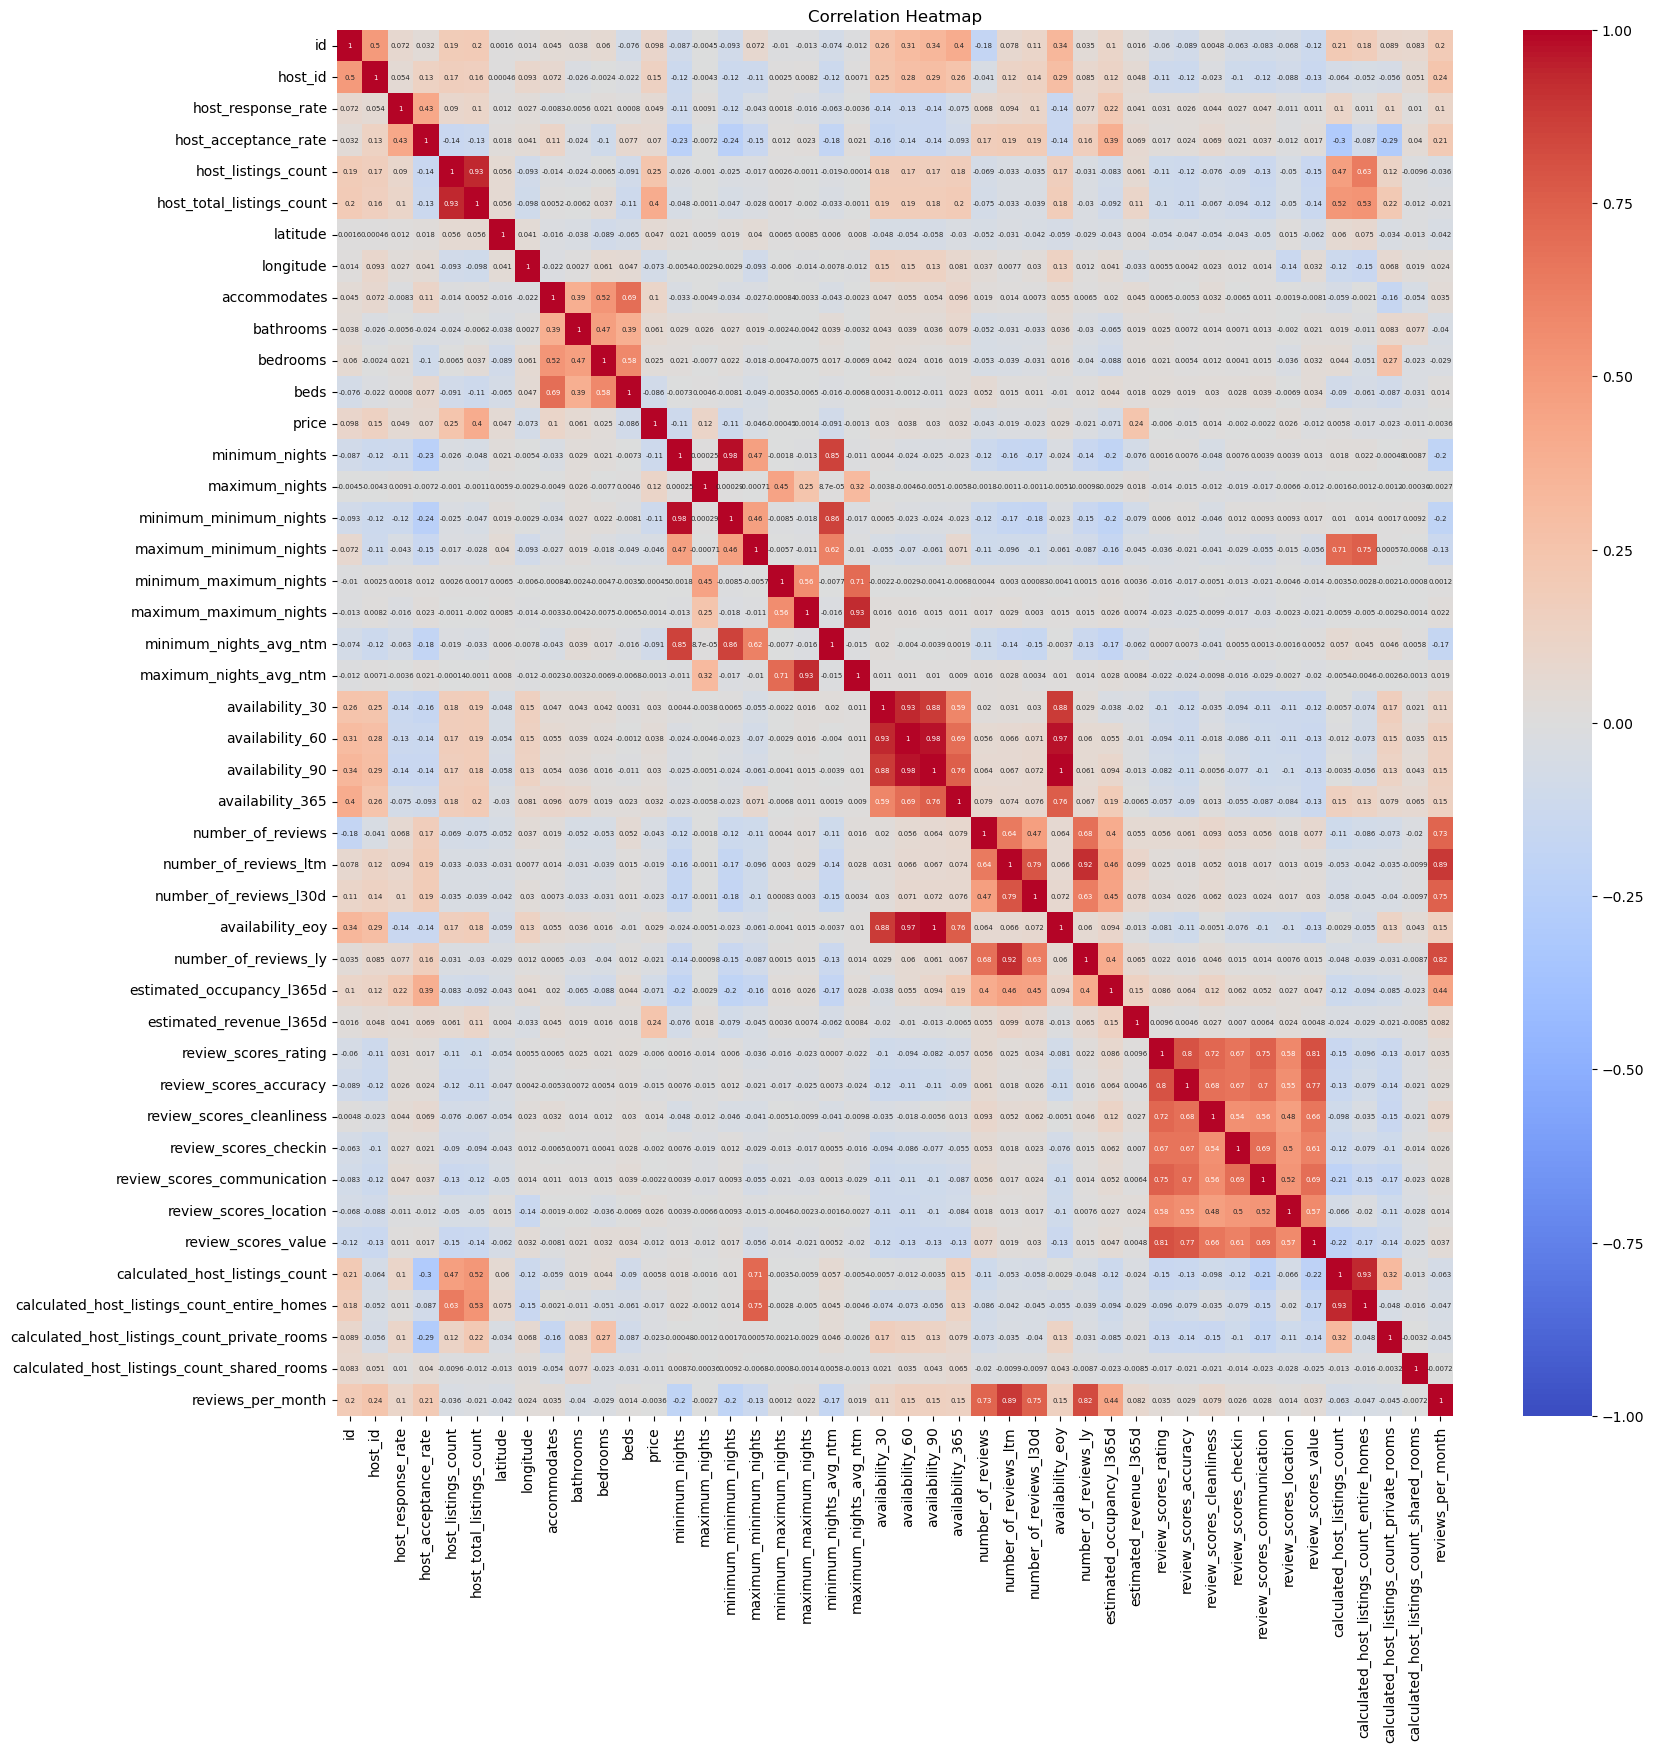

In [15]:
plt.figure(figsize=(18,18))
sns.heatmap(corr1, vmin=-1, vmax=1, center=0, annot=True, cmap="coolwarm", annot_kws={"fontsize":5})
plt.title("Correlation Heatmap")
plt.show()

## 2. Data cleansing

## *Column dropping decision

In [16]:
#minimum nights and maximum nights: keep the main one only

In [17]:
#availability: Keep only _30 and _365 as the mimimum values and maximum value for the range of availability

In [18]:
#number of reviews, review scores rating, calculated host listings counts: keep the main one only

In [19]:
#reviews_per_month: drop as it highly correlated to number_of_reviews

In [20]:
#as property type and room type show overlapping values >> drop the former one as it contains too many texts, we will just focus on the general listing types only

In [21]:
newyork["property_type"].value_counts()

property_type
Entire rental unit             15253
Private room in rental unit     9852
Private room in home            2629
Room in hotel                   1426
Entire home                     1247
                               ...  
Private room in in-law             1
Private room in tent               1
Entire bed and breakfast           1
Cave                               1
Dome                               1
Name: count, Length: 74, dtype: int64

In [22]:
newyork["room_type"].value_counts()

room_type
Entire home/apt    19167
Private room       16350
Hotel room           351
Shared room          243
Name: count, dtype: int64

==> Consider keeping only room_type, as property_type contains text, and it is redundant to room_type

In [23]:
listing["host_listings_count"].isnull().sum()

np.int64(1167)

In [24]:
listing["calculated_host_listings_count"].isnull().sum()

np.int64(0)

### ***Decision: May consider dropping:
- Pure identifiers / URLs
- Descriptive text / unstructured info
- Time-related
- Metadata (rarely useful in cross-section)
- Duplicative / overly detailed geographic or host info
- Columns that are aggregations of others (redundant)



In [25]:
newyork.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [26]:
newyork.drop(columns=['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 
                      'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about',  'host_response_time', 'host_thumbnail_url', 
                      'host_picture_url', 'host_neighbourhood', 'host_listings_count','host_verifications', 'host_has_profile_pic', 
                      'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'latitude', 'longitude', 
                      'property_type', 'bathrooms_text', 'amenities', 'minimum_minimum_nights', 'maximum_minimum_nights', 
                       'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated',
                      'availability_60', 'availability_90', 'calendar_last_scraped', 'number_of_reviews_ltm', 
                       'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d','estimated_revenue_l365d', 
                       'first_review', 'last_review', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
                       'review_scores_communication', 'review_scores_location', 'review_scores_value', 'license', 
                      'calculated_host_listings_count_entire_homes',
                       'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 
                      'reviews_per_month'], inplace=True)   

In [27]:
newyork.shape 
#same number of obs, yet the #cols was reduced to 20

(36111, 20)

In [28]:
newyork.columns #after cleansing

Index(['host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'neighbourhood_group_cleansed',
       'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'has_availability',
       'availability_30', 'availability_365', 'number_of_reviews',
       'review_scores_rating', 'instant_bookable',
       'calculated_host_listings_count'],
      dtype='object')

In [29]:
newyork.isnull().values.any()

np.True_

In [30]:
newyork.isnull().sum()

host_response_rate                15774
host_acceptance_rate              15595
host_is_superhost                   384
host_total_listings_count          1167
neighbourhood_group_cleansed          0
room_type                             0
accommodates                          0
bathrooms                         14411
bedrooms                           5949
beds                              14468
price                             14783
minimum_nights                        0
maximum_nights                        0
has_availability                   5665
availability_30                       0
availability_365                      0
number_of_reviews                     0
review_scores_rating              11188
instant_bookable                      0
calculated_host_listings_count        0
dtype: int64

In [31]:
newyork["has_availability"].value_counts()

has_availability
t    30446
Name: count, dtype: int64

*has_availability used to indicate if a listing is active and available for booking. It's often used in data analysis, where t (true) means the listing is active and f (false) means it is not ==> drop obs that are not available on Airbnb

In [32]:
newyork.dropna(subset=['has_availability'], inplace=True)

In [33]:
newyork.isnull().sum() #after dropping NA in has_availability

host_response_rate                10261
host_acceptance_rate              10104
host_is_superhost                   372
host_total_listings_count          1160
neighbourhood_group_cleansed          0
room_type                             0
accommodates                          0
bathrooms                          9000
bedrooms                           3801
beds                               9057
price                              9372
minimum_nights                        0
maximum_nights                        0
has_availability                      0
availability_30                       0
availability_365                      0
number_of_reviews                     0
review_scores_rating               8346
instant_bookable                      0
calculated_host_listings_count        0
dtype: int64

In [34]:
newyork.shape

(30446, 20)

### *Dependent variable: Price

In [35]:
newyork["price"].describe() #original 'price' data

count    21074.000000
mean       686.502800
std       4507.003427
min         10.000000
25%         89.000000
50%        154.000000
75%        280.000000
max      50104.000000
Name: price, dtype: float64

==> It is shown that the distribution of price is right-skewed with the median < mean. Also, it was observed that the 'price' variable contains extreme outliers, as the max is 50,104, while the 75th percentile is only 279. That’s >170× larger than typical prices

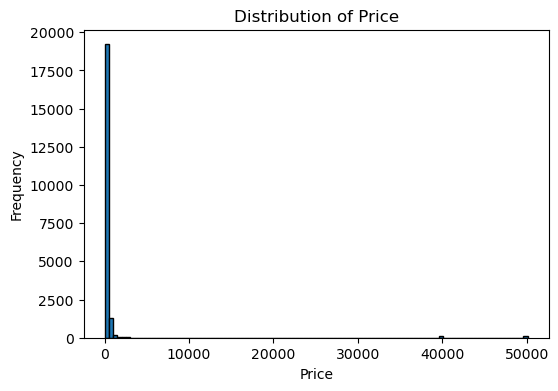

In [36]:
plt.figure(figsize=(6,4))
plt.hist(newyork["price"], bins=100, edgecolor='black')
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [37]:
numeric_cols2 = newyork.select_dtypes(include=['float64', 'int64']).columns

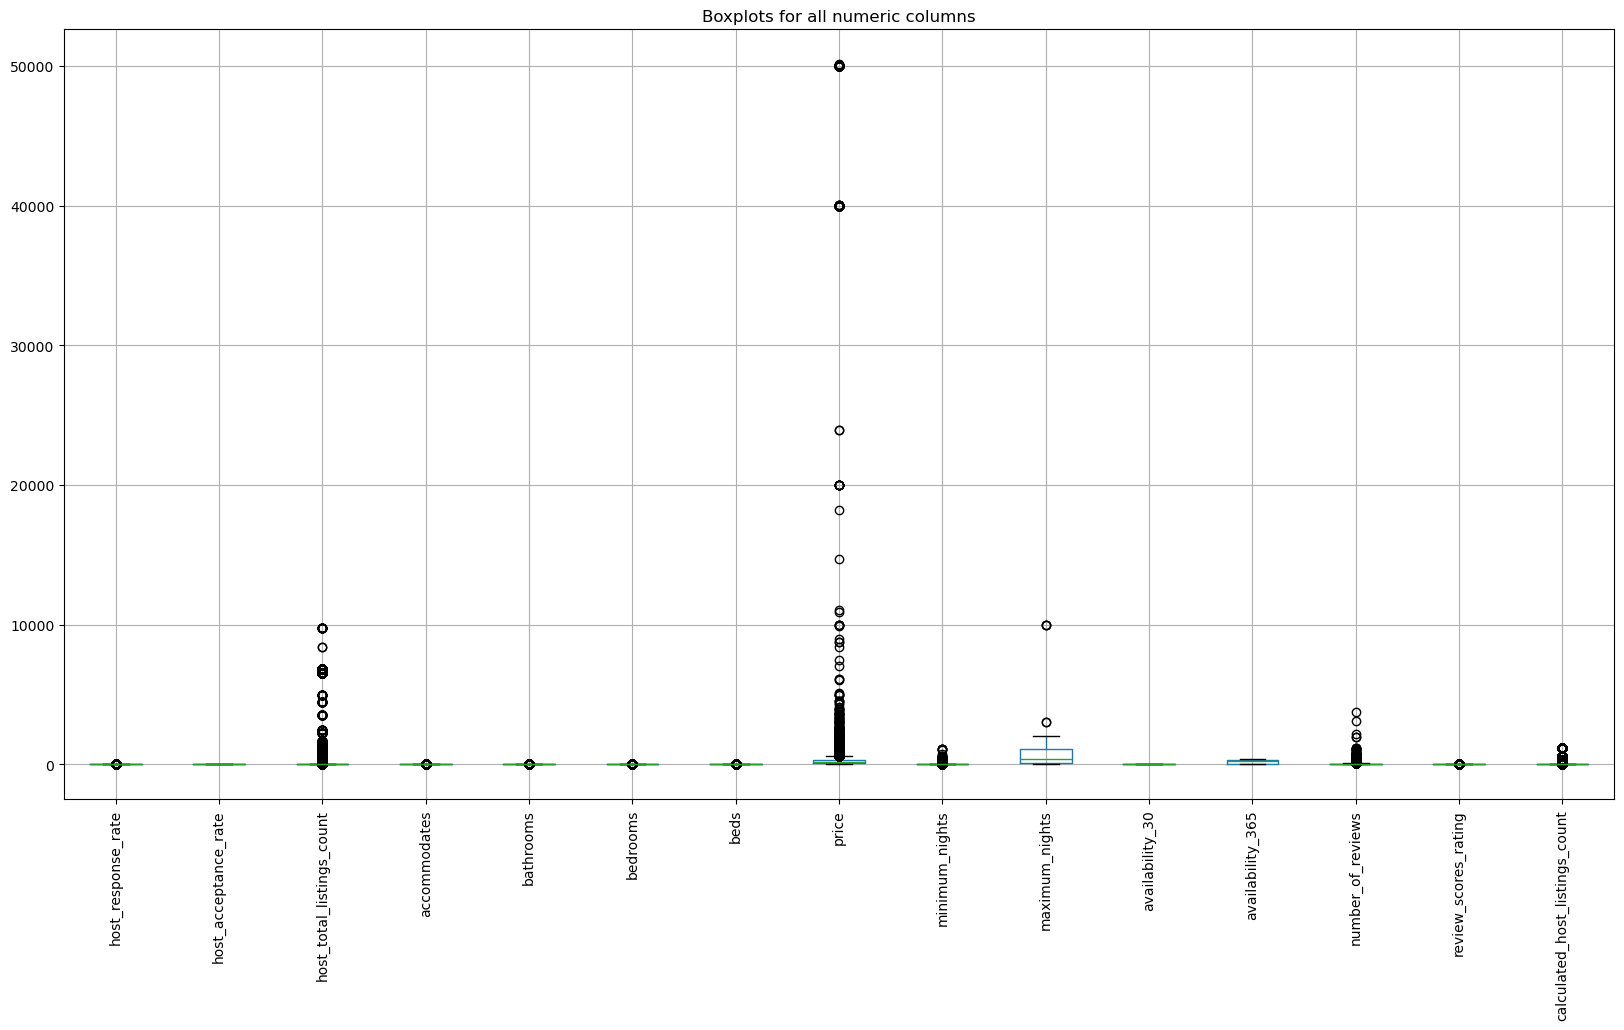

In [38]:
newyork[numeric_cols2].boxplot(figsize=(20,10), rot=90)
plt.title('Boxplots for all numeric columns')
plt.show()

In [39]:
import numpy as np

In [40]:
newyork["log_price"] = np.log(newyork["price"]+1)

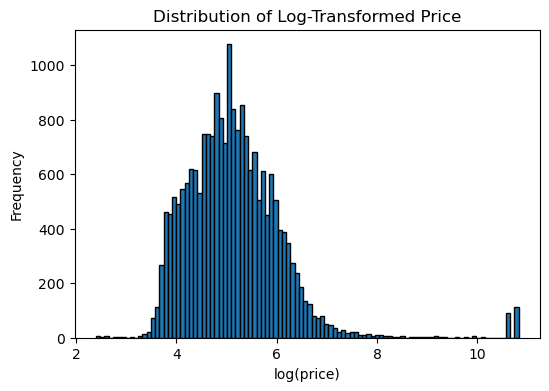

In [41]:
plt.figure(figsize=(6,4))
plt.hist(newyork["log_price"], bins=100, edgecolor='black')
plt.title("Distribution of Log-Transformed Price")
plt.xlabel("log(price)")
plt.ylabel("Frequency")
plt.show()

==> Observation:
- The distribution of log_price is approximately normal (bell-shaped), which is more suitable for linear regression.

- The original price variable had extreme right skewness and many outliers, but the log transformation has reduced skewness and stabilized variance.

- A few high values remain, but they are not extreme anymore and do not require removal at this stage.

- Outliers will not be removed since they may represent real high-value Airbnb listings.

- Missing values in price (and therefore log_price) will be dropped before regression, because regression cannot handle missing target values.

In [42]:
#Removing missing values in price

In [43]:
newyork.dropna(subset=['price'], inplace=True)

In [44]:
newyork["price"].isnull().values.any()

np.False_

In [45]:
newyork["price"].describe() 

count    21074.000000
mean       686.502800
std       4507.003427
min         10.000000
25%         89.000000
50%        154.000000
75%        280.000000
max      50104.000000
Name: price, dtype: float64

### *Independent variables

In [46]:
newyork.isnull().sum() #after dropping missing values in price

host_response_rate                3975
host_acceptance_rate              4145
host_is_superhost                  308
host_total_listings_count         1042
neighbourhood_group_cleansed         0
room_type                            0
accommodates                         0
bathrooms                            7
bedrooms                            85
beds                                41
price                                0
minimum_nights                       0
maximum_nights                       0
has_availability                     0
availability_30                      0
availability_365                     0
number_of_reviews                    0
review_scores_rating              6141
instant_bookable                     0
calculated_host_listings_count       0
log_price                            0
dtype: int64

In [47]:
#host_response_rate >> mean substitution

In [48]:
newyork["host_response_rate"].describe()

count    17099.000000
mean         0.891377
std          0.246290
min          0.000000
25%          0.930000
50%          1.000000
75%          1.000000
max          1.000000
Name: host_response_rate, dtype: float64

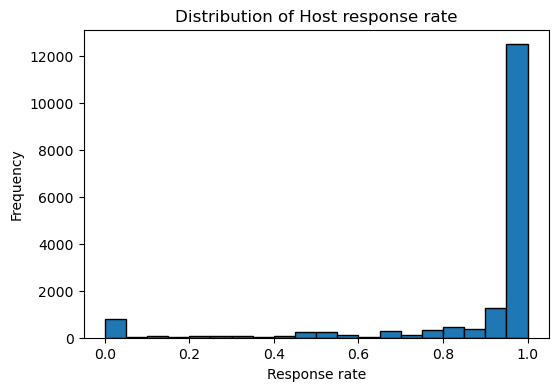

In [49]:
plt.figure(figsize=(6,4))
plt.hist(newyork["host_response_rate"], bins=20, edgecolor='black')
plt.title("Distribution of Host response rate")
plt.xlabel("Response rate")
plt.ylabel("Frequency")
plt.show()

In [50]:
response_rate_mean = newyork["host_response_rate"].mean()
response_rate_mean

np.float64(0.8913766886952454)

In [51]:
newyork.fillna({"host_response_rate": response_rate_mean}, inplace = True)

In [52]:
#host_acceptance_rate >> mean substitution

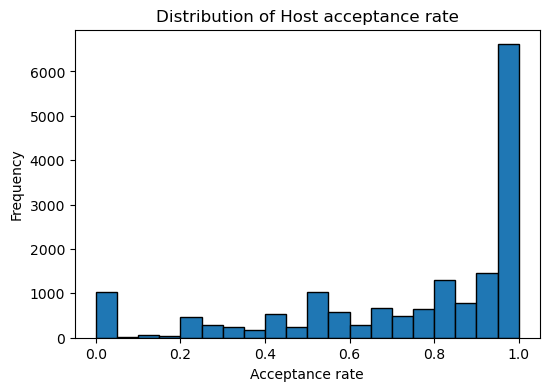

In [53]:
plt.figure(figsize=(6,4))
plt.hist(newyork["host_acceptance_rate"], bins=20, edgecolor='black')
plt.title("Distribution of Host acceptance rate")
plt.xlabel("Acceptance rate")
plt.ylabel("Frequency")
plt.show()

In [54]:
acceptance_rate_mean = newyork["host_acceptance_rate"].mean()
acceptance_rate_mean

np.float64(0.7494536003307933)

In [55]:
newyork.fillna({"host_acceptance_rate": acceptance_rate_mean}, inplace = True)

In [56]:
newyork.isnull().sum()

host_response_rate                   0
host_acceptance_rate                 0
host_is_superhost                  308
host_total_listings_count         1042
neighbourhood_group_cleansed         0
room_type                            0
accommodates                         0
bathrooms                            7
bedrooms                            85
beds                                41
price                                0
minimum_nights                       0
maximum_nights                       0
has_availability                     0
availability_30                      0
availability_365                     0
number_of_reviews                    0
review_scores_rating              6141
instant_bookable                     0
calculated_host_listings_count       0
log_price                            0
dtype: int64

In [57]:
#review_scores_rating >> mean substitution

In [58]:
newyork["review_scores_rating"].describe()

count    14933.000000
mean         4.731092
std          0.447853
min          1.000000
25%          4.670000
50%          4.860000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64

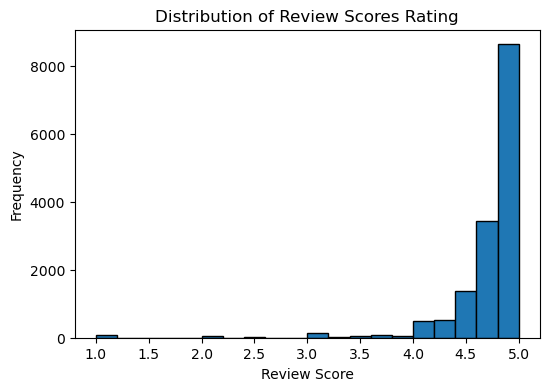

In [59]:
plt.figure(figsize=(6,4))
plt.hist(newyork["review_scores_rating"], bins=20, edgecolor='black')
plt.title("Distribution of Review Scores Rating")
plt.xlabel("Review Score")
plt.ylabel("Frequency")
plt.show()

In [60]:
rv_score_mean = newyork["review_scores_rating"].mean()
rv_score_mean

np.float64(4.731091542221924)

In [61]:
newyork.fillna({"review_scores_rating": rv_score_mean}, inplace = True)

In [62]:
newyork.isnull().sum()

host_response_rate                   0
host_acceptance_rate                 0
host_is_superhost                  308
host_total_listings_count         1042
neighbourhood_group_cleansed         0
room_type                            0
accommodates                         0
bathrooms                            7
bedrooms                            85
beds                                41
price                                0
minimum_nights                       0
maximum_nights                       0
has_availability                     0
availability_30                      0
availability_365                     0
number_of_reviews                    0
review_scores_rating                 0
instant_bookable                     0
calculated_host_listings_count       0
log_price                            0
dtype: int64

In [63]:
newyork.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,neighbourhood_group_cleansed,room_type,accommodates,bathrooms,bedrooms,beds,...,minimum_nights,maximum_nights,has_availability,availability_30,availability_365,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count,log_price
0,1.000000,0.54,t,3.0,Queens,Private room,1,1.0,1.0,1.0,...,30,365,t,16,77,16,4.81,f,3,4.204693
4,0.900000,0.69,t,16.0,Manhattan,Private room,1,2.0,1.0,1.0,...,30,900,t,26,168,20,4.95,f,8,4.343805
5,0.750000,1.00,t,2.0,Queens,Entire home/apt,6,1.0,2.0,3.0,...,30,365,t,29,364,93,4.14,f,2,4.584967
7,0.891377,0.60,t,1.0,Brooklyn,Private room,1,1.0,2.0,1.0,...,30,35,t,0,187,26,4.92,f,1,4.110874
8,0.000000,0.00,f,9.0,Brooklyn,Entire home/apt,6,4.0,3.0,3.0,...,30,90,t,20,224,1,5.00,f,1,6.054439


In [64]:
#host is superhost >> mode substitute

In [65]:
newyork["host_is_superhost"].value_counts()

host_is_superhost
f    14372
t     6394
Name: count, dtype: int64

In [66]:
host_is_superhost_mode = newyork["host_is_superhost"].mode()[0]
host_is_superhost_mode

'f'

In [67]:
newyork.fillna({"host_is_superhost": host_is_superhost_mode}, inplace = True)

In [68]:
#host total listing count >>  mode substitute

In [69]:
host_total_listings_count_mode = newyork["host_total_listings_count"].mode()[0]
host_total_listings_count_mode

np.float64(1.0)

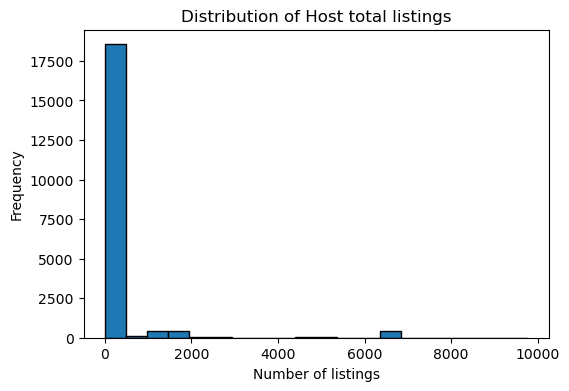

In [70]:
plt.figure(figsize=(6,4))
plt.hist(newyork["host_total_listings_count"], bins=20, edgecolor='black')
plt.title("Distribution of Host total listings")
plt.xlabel("Number of listings")
plt.ylabel("Frequency")
plt.show()

In [71]:
newyork.fillna({"host_total_listings_count": host_total_listings_count_mode}, inplace = True)

In [72]:
#bathrooms  >> mode substitute

In [73]:
newyork["bathrooms"].value_counts()

bathrooms
1.0     16455
2.0      2597
1.5       900
0.0       373
3.0       249
2.5       225
4.0        75
0.5        69
3.5        65
4.5        20
5.0        15
6.0         8
5.5         6
7.5         4
7.0         2
15.5        1
10.5        1
9.0         1
6.5         1
Name: count, dtype: int64

In [74]:
bathrooms_mode = newyork["bathrooms"].mode()[0]
bathrooms_mode

np.float64(1.0)

In [75]:
newyork.fillna({"bathrooms": bathrooms_mode}, inplace = True)

In [76]:
#bedroom  >> mode substitute

In [77]:
bedrooms_mode = newyork["bedrooms"].mode()[0]
bedrooms_mode

np.float64(1.0)

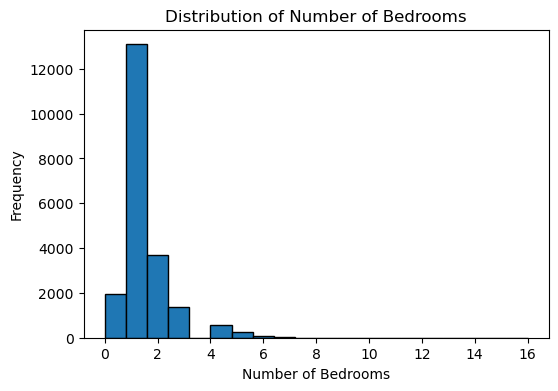

In [78]:
plt.figure(figsize=(6,4))
plt.hist(newyork["bedrooms"], bins=20, edgecolor='black')
plt.title("Distribution of Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Frequency")
plt.show()

In [79]:
newyork.fillna({"bedrooms": bedrooms_mode}, inplace = True)

In [80]:
newyork.isnull().sum()

host_response_rate                 0
host_acceptance_rate               0
host_is_superhost                  0
host_total_listings_count          0
neighbourhood_group_cleansed       0
room_type                          0
accommodates                       0
bathrooms                          0
bedrooms                           0
beds                              41
price                              0
minimum_nights                     0
maximum_nights                     0
has_availability                   0
availability_30                    0
availability_365                   0
number_of_reviews                  0
review_scores_rating               0
instant_bookable                   0
calculated_host_listings_count     0
log_price                          0
dtype: int64

In [81]:
#bed >>  mode substitute

In [82]:
newyork["beds"].value_counts()

beds
1.0     12269
2.0      4803
3.0      1762
4.0       844
0.0       755
5.0       305
6.0       143
7.0        69
8.0        42
9.0        13
10.0        8
12.0        5
11.0        4
13.0        4
19.0        2
16.0        2
40.0        1
17.0        1
21.0        1
Name: count, dtype: int64

In [83]:
beds_mode = newyork["beds"].mode()[0]
beds_mode

np.float64(1.0)

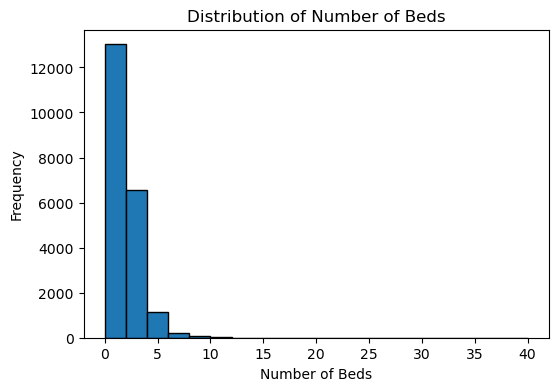

In [84]:
plt.figure(figsize=(6,4))
plt.hist(newyork["beds"], bins=20, edgecolor='black')
plt.title("Distribution of Number of Beds")
plt.xlabel("Number of Beds")
plt.ylabel("Frequency")
plt.show()

In [85]:
newyork.fillna({"beds": beds_mode}, inplace = True)

In [86]:
newyork.isnull().sum() #all missing values were handled

host_response_rate                0
host_acceptance_rate              0
host_is_superhost                 0
host_total_listings_count         0
neighbourhood_group_cleansed      0
room_type                         0
accommodates                      0
bathrooms                         0
bedrooms                          0
beds                              0
price                             0
minimum_nights                    0
maximum_nights                    0
has_availability                  0
availability_30                   0
availability_365                  0
number_of_reviews                 0
review_scores_rating              0
instant_bookable                  0
calculated_host_listings_count    0
log_price                         0
dtype: int64

In [87]:
newyork.shape

(21074, 21)